In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries ready!")

Libraries ready!


In [26]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset loaded!")
df

Dataset loaded!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
# 1. Age — median se fill karo
df['Age'].fillna(df['Age'].median(), inplace=True)

# 2. Embarked — mode se fill karo
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 3. Cabin — drop kar do (bahut zyada missing)
df.drop(columns=['Cabin'], inplace=True)

# Verify karo
df.isnull().sum()

C:\Users\BIT PATNA\AppData\Local\Temp\ipykernel_23748\3785750495.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [32]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [33]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [35]:
s=df['Survived'].value_counts(normalize=True).round(2)
s*100

Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

In [37]:
print(df.groupby('Sex')['Survived'].mean().round(2)*100)

Sex
female    74.0
male      19.0
Name: Survived, dtype: float64


In [39]:
print(df.groupby('Pclass')['Survived'].mean().round(2)*100)

Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64


In [42]:
s=df['Survived'].value_counts(normalize=True).round(2)

print(s*100)
print(df.groupby('Sex')['Survived'].mean().round(2)*100)
print(df.groupby('Pclass')['Survived'].mean().round(2)*100)

Survived
0    62.0
1    38.0
Name: proportion, dtype: float64
Sex
female    74.0
male      19.0
Name: Survived, dtype: float64
Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64


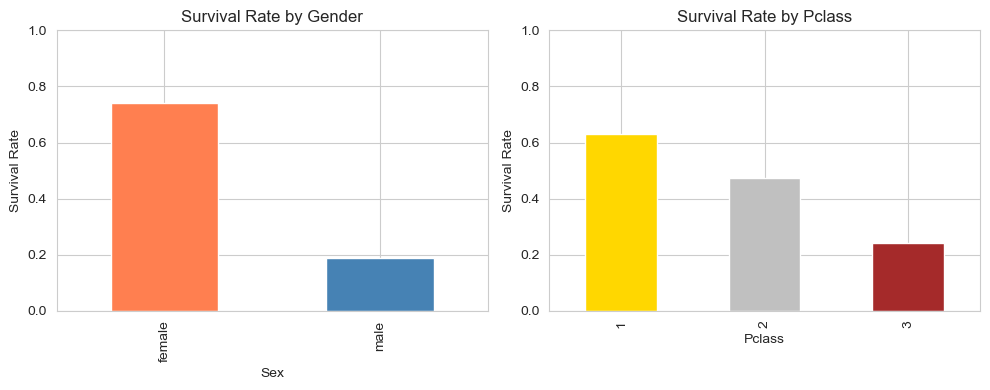

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['coral', 'steelblue']
)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)


df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['gold', 'silver', 'brown']
)
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

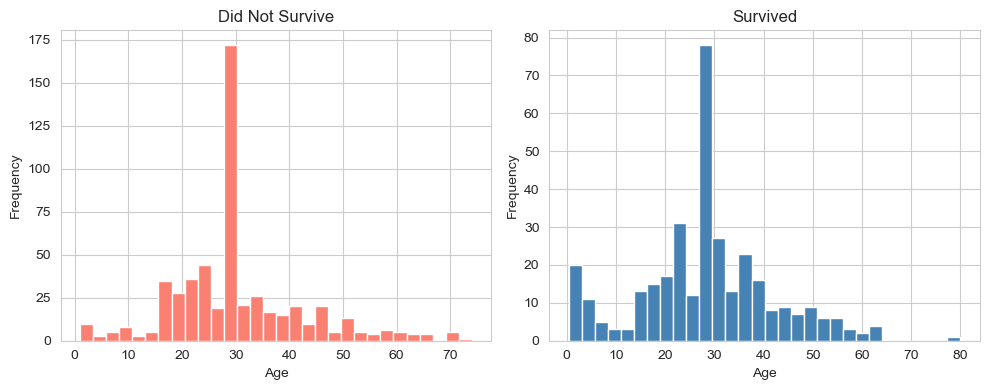

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


df[df['Survived'] == 0]['Age'].plot(
    kind='hist', bins=30, ax=axes[0],
    color='salmon', title='Did Not Survive'
)


df[df['Survived'] == 1]['Age'].plot(
    kind='hist', bins=30, ax=axes[1],
    color='steelblue', title='Survived'
)

axes[0].set_xlabel('Age')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# EDA CONCLUSIONS — Titanic Dataset
# ============================================

# 1. Overall survival rate sirf 38% tha
# 2. Females ka survival rate 74% tha vs males ka 19%
# 3. 1st class passengers 63% survive kiye, 3rd class sirf 24%
# 4. Chhote bacche (0-10) proportionally zyada survive kiye
# 5. Age 20-30 ke log sabse zyada the — dono groups mein